In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#REGRESSION MODEL
df = pd.read_csv("mumbai_housing.csv")
print(df.head())
print(df.info())


   longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
0  72.948078  19.089566                  33         1438             770   
1  72.805871  19.197064                  31         4275            1624   
2  72.828369  19.080637                  49          694             439   
3  72.893222  19.028291                  38         2400            1126   
4  72.927956  19.092998                  22         4918            1885   

   population  households  median_income  median_house_value ocean_proximity  
0        3061        1133       0.416899        1.641025e+06      NEAR OCEAN  
1        1208         458       0.432243        7.639323e+05      NEAR OCEAN  
2        4886         367       1.196992        2.723921e+06      NEAR OCEAN  
3         595        2488       1.028650        9.722198e+05      NEAR OCEAN  
4        4482         632       1.391500        4.670827e+06      NEAR OCEAN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to

In [4]:
print(df.isnull().sum())        # check missing values
print(df.describe())            # sanity check ranges

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64
          longitude      latitude  housing_median_age   total_rooms  \
count  20000.000000  20000.000000        20000.000000  20000.000000   
mean      72.870910     19.117576           27.071000   3147.704200   
std        0.045743      0.084229           12.994249   1645.947014   
min       72.776437     18.895455            5.000000    300.000000   
25%       72.834096     19.053935           16.000000   1731.000000   
50%       72.867199     19.129132           27.000000   3161.000000   
75%       72.906749     19.184163           38.000000   4568.000000   
max       72.979366     19.269862           49.000000   5999.000000   

       total_bedrooms    population    households  median_income  \
count    20000.000000  20000.000000  20

In [5]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [6]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [7]:
df_original = pd.read_csv("mumbai_housing.csv")
print(df_original['ocean_proximity'].value_counts())

ocean_proximity
NEAR OCEAN    20000
Name: count, dtype: int64


In [8]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [11]:
y_pred = rf_model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  230929.81
RMSE: 468357.29
R²:   0.9659


In [2]:
#CLASSIFICATION MODEL
import pandas as pd
import numpy as np

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df_adult = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

print(df_adult.shape)
print(df_adult.head())

(32561, 15)
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0 

In [3]:
print(df_adult.info())
print(df_adult['income'].value_counts())
print(df_adult.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
age               0
workc

In [4]:
df_adult['income'] = df_adult['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
print(df_adult['income'].value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


In [5]:
categorical_cols = ['workclass', 'education', 'marital_status', 'occupation',
                     'relationship', 'race', 'sex', 'native_country']

df_adult = pd.get_dummies(df_adult, columns=categorical_cols, drop_first=True)
print(df_adult.shape)

(32561, 101)


In [6]:
X_adult = df_adult.drop('income', axis=1)
y_adult = df_adult['income']

In [7]:
from sklearn.model_selection import train_test_split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42, stratify=y_adult
)

print("Train shape:", X_train_a.shape)
print("Test shape:", X_test_a.shape)

Train shape: (26048, 100)
Test shape: (6513, 100)


In [8]:
from sklearn.ensemble import RandomForestClassifier

clf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
clf_model.fit(X_train_a, y_train_a)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [9]:
y_pred_a = clf_model.predict(X_test_a)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test_a, y_pred_a)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test_a, y_pred_a, target_names=['<=50K', '>50K']))

print("Confusion Matrix:")
print(confusion_matrix(y_test_a, y_pred_a))

Accuracy: 0.8607

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.75      0.63      0.69      1568

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513

Confusion Matrix:
[[4611  334]
 [ 573  995]]


<Axes: >

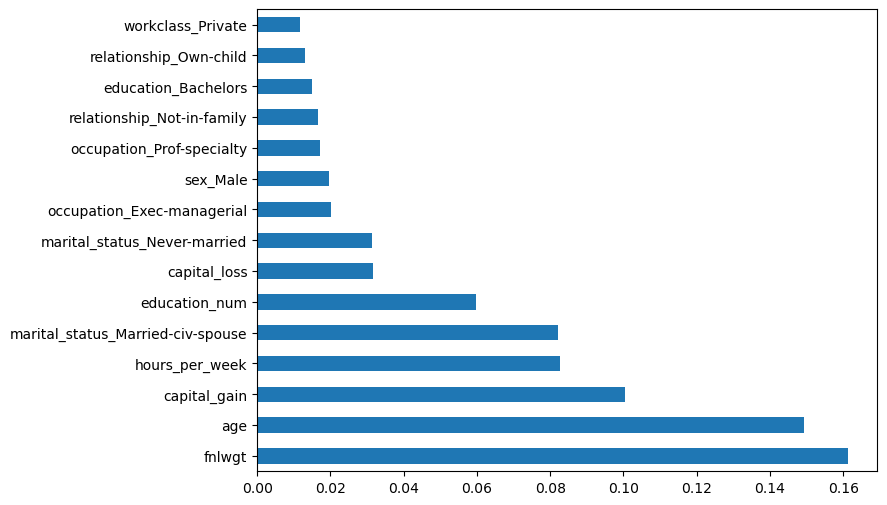

In [11]:
importances = pd.Series(clf_model.feature_importances_, index=X_adult.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))